This tutorial covers the basics of text processing.

**ILOs**

After completing this tutorial the student 

* can read corpora from disk and represent it in a computer
* appreciates the challenges in text normalisation
* can use NLTK to load corpora
* can use NLTK to pre-process text
* can analyse basic properties of text (e.g., length distribution, word frequency distribution)
* can implement a unigram language model (estimate its parameters and generate sentences from it)

---


**Table of contents**

* [Corpora](#corpora)
* [NLTK](#nltk)
    * [Segmentation](#segmentation) 
* [Analysing Basic Properties of Corpora](#analysis)
    * [Sentence Length](#length)
    * [Vocabulary](#vocabulary)
* [Unigram Language Model](#unigram)
    


**Files**

If you are running on **colab** you will need to download some files:

In [1]:
import os

if not os.path.exists('wsj_sample.txt'):
    !wget https://raw.githubusercontent.com/probabll/ntmi-tutorials/master/T1/wsj_sample.txt        
if not os.path.exists('wsj_sample_split.txt'):
    !wget https://raw.githubusercontent.com/probabll/ntmi-tutorials/master/T1/wsj_sample_split.txt        
if not os.path.exists('twitter_sample.txt'):
    !wget https://raw.githubusercontent.com/probabll/ntmi-tutorials/master/T1/twitter_sample.txt        
if not os.path.exists('test_a.txt'):
    !wget https://raw.githubusercontent.com/probabll/ntmi-tutorials/master/T1/test_a.txt        
if not os.path.exists('test_b.txt'):
    !wget https://raw.githubusercontent.com/probabll/ntmi-tutorials/master/T1/test_b.txt                

# <a name="corpora">  Corpora

In this course we will concentrate on natural language processing applications involving **written text**. This in contrast, for example, with speech signal in tasks such as speech recognition or simultaneous translation.

A so called **corpus** (plural *corpora*) is a collection of textual units such as sentences, paragraphs, or documents. 

One rather well known English corpus in NLP is the [Wall Street Journal](https://catalog.ldc.upenn.edu/LDC2000T43), a sample of which can be found in `wsj_sample.txt`.

You can open files in python using `open` in **r**ead mode:

In [2]:
with open('wsj_sample.txt', 'r') as fi:
    wsj = fi.readlines()

When you download a corpus you may find a structured collection of units (e.g., a collection of newline-separated sentences, a collection of documents organised via XML-markup), a single chunk of text, or a mix of the two. This particular sample of the WSJ corpus is a unstructured block of text:

In [3]:
print("There is {} line of characters in wsj_sample.txt ".format(len(wsj)))

There is 1 line of characters in wsj_sample.txt 


A rather long block of text:

In [4]:
print("This line is {}-characters long!".format(len(wsj[0])))

This line is 4990028-characters long!


Let's inspect the first 575 characters:

In [5]:
wsj575_raw = wsj[0][:575]
wsj575_raw

"In an Oct. 19 review of The Misanthrope at Chicago's Goodman Theatre (Revitalized Classics Take the Stage in Windy City, Leisure & Arts), the role of Celimene, played by Kim Cattrall, was mistakenly attributed to Christina Haag. Ms. Haag plays Elianti. Rolls-Royce Motor Cars Inc. said it expects its U.S. sales to remain steady at about 1,200 cars in 1990. The luxury auto maker last year sold 1,214 cars in the U.S. Howard Mosher, president and chief executive officer, said he anticipates growth for the luxury auto maker in Britain and Europe, and in Far Eastern markets."

The excerpt above illustrates well a few of the first challenges with written text: segmentation.

We may want to split a chunk of text into relevant units, perhaps those are sentences, which are generally clearly marked in English. We may want to further split a sentence in clauses, clauses into words, perhaps separate punctuation from words themselves. And mind that all of that is language specific. Some languages do not have punctuation, word boundaries, sentence boundaries, etc. 

If you are not convinced, The simplest strategy might use punctuation as an indicator of sentence boundary. *Sentence-splitting* (i.e., identifying sentences) looks simple at first, but note how `.` in `Oct.` does not delimit a sentence. Something similar can be said about *tokenization* (i.e., separating words from punctuation), note how `,` in `1,214` does not separate two tokens. 

Next we illustrate two native algorithms, one for sentence splitting, one for tokenization. See how they make arguably bad decisions in context.

In [6]:
def naive_splitter(text, delimiters=""".!?"""):
    sentences = []
    start = 0
    for i, ch in enumerate(text):  # scan the string
        if ch in delimiters or i + 1 == len(text):  # looking for a delimiter or the end of the string
            sentence = text[start:i + 1].strip()  # we've found a "sentence" (as far as our delimiters suggest)
            if sentence:
                sentences.append(sentence)
            start = i + 1
    return sentences

def naive_tokenizer(text, delimiters=""",-;:'"()/&"""):
    sentences = []
    start = 0
    for i, ch in enumerate(text): # scane the string
        if ch in delimiters or ch in ' \t' or i + 1 == len(text):  # looking for a delimiter or empty space
            token = text[start:i].strip()  # we've found a "token" (as far as our delimiters suggest)
            if token:
                sentences.append(token)
            if ch not in ' \t':  # in tokenization, we interpret delimiters as tokens
                sentences.append(ch)
            start = i + 1
    return sentences

The demonstration below shows that our splitter finds many more sentences than a reasonable reader would identify. For example, `Oct.` was a short for October in a much longer sentence. Look at what happened to `U.S.`. We also make bad tokenization decisions, for example, the numeral `1,200` was space-separated into 3 tokens (namely, `1`, `,`, and `200`).

In [7]:
for i, sentence in enumerate(naive_splitter(wsj575_raw), 1):
    tokens = naive_tokenizer(sentence)
    print('Sentence {:2d} ({:2d} tokens):'.format(i, len(tokens)), tokens)    

Sentence  1 ( 4 tokens): ['In', 'an', 'Oct', '.']
Sentence  2 (43 tokens): ['19', 'review', 'of', 'The', 'Misanthrope', 'at', 'Chicago', "'", 's', 'Goodman', 'Theatre', '(', 'Revitalized', 'Classics', 'Take', 'the', 'Stage', 'in', 'Windy', 'City', ',', 'Leisure', '&', 'Arts', ')', ',', 'the', 'role', 'of', 'Celimene', ',', 'played', 'by', 'Kim', 'Cattrall', ',', 'was', 'mistakenly', 'attributed', 'to', 'Christina', 'Haag', '.']
Sentence  3 ( 2 tokens): ['Ms', '.']
Sentence  4 ( 4 tokens): ['Haag', 'plays', 'Elianti', '.']
Sentence  5 ( 7 tokens): ['Rolls', '-', 'Royce', 'Motor', 'Cars', 'Inc', '.']
Sentence  6 ( 6 tokens): ['said', 'it', 'expects', 'its', 'U', '.']
Sentence  7 ( 2 tokens): ['S', '.']
Sentence  8 (13 tokens): ['sales', 'to', 'remain', 'steady', 'at', 'about', '1', ',', '200', 'cars', 'in', '1990', '.']
Sentence  9 (15 tokens): ['The', 'luxury', 'auto', 'maker', 'last', 'year', 'sold', '1', ',', '214', 'cars', 'in', 'the', 'U', '.']
Sentence 10 ( 2 tokens): ['S', '.']
Se

Segmentation mostly serves the purpose of simplifying processing and analysis. As we will see in this course, simpler units are easier to manage computationally and they are more easily integrated in statistical models.

For example, the following cell illustrates how the linguists involved in the [English Penn Treebank project](https://www.aclweb.org/anthology/J93-2004/) would have segmented the previous excerpt into 5 sentences using `\n` (newline) as a sentence delimiter.

In [8]:
wsj575_segmented = """In an Oct. 19 review of The Misanthrope at Chicago's Goodman Theatre (Revitalized Classics Take the Stage in Windy City, Leisure & Arts), the role of Celimene, played by Kim Cattrall, was mistakenly attributed to Christina Haag.
Ms. Haag plays Elianti.
Rolls-Royce Motor Cars Inc. said it expects its U.S. sales to remain steady at about 1,200 cars in 1990.
The luxury auto maker last year sold 1,214 cars in the U.S.
Howard Mosher, president and chief executive officer, said he anticipates growth for the luxury auto maker in Britain and Europe, and in Far Eastern markets."""

In [9]:
for i, sentence in enumerate(wsj575_segmented.split('\n'), 1):  # split newline-separated sentences
    print("Sentence {:2d}:".format(i), sentence)

Sentence  1: In an Oct. 19 review of The Misanthrope at Chicago's Goodman Theatre (Revitalized Classics Take the Stage in Windy City, Leisure & Arts), the role of Celimene, played by Kim Cattrall, was mistakenly attributed to Christina Haag.
Sentence  2: Ms. Haag plays Elianti.
Sentence  3: Rolls-Royce Motor Cars Inc. said it expects its U.S. sales to remain steady at about 1,200 cars in 1990.
Sentence  4: The luxury auto maker last year sold 1,214 cars in the U.S.
Sentence  5: Howard Mosher, president and chief executive officer, said he anticipates growth for the luxury auto maker in Britain and Europe, and in Far Eastern markets.


And the following is how the same linguists would have *tokenized* those sentences using ` ` (space) as a token delimiter:

In [10]:
wsj575_tokenized = """In an Oct. 19 review of The Misanthrope at Chicago 's Goodman Theatre ( Revitalized Classics Take the Stage in Windy City , Leisure & Arts ) , the role of Celimene , played by Kim Cattrall , was mistakenly attributed to Christina Haag .
Ms. Haag plays Elianti .
Rolls-Royce Motor Cars Inc. said it expects its U.S. sales to remain steady at about 1,200 cars in 1990 .
The luxury auto maker last year sold 1,214 cars in the U.S.
Howard Mosher , president and chief executive officer , said he anticipates growth for the luxury auto maker in Britain and Europe , and in Far Eastern markets ."""

In [11]:
for i, sentence in enumerate(wsj575_tokenized.split('\n'), 1):  # split newline-separated sentences
    tokens = sentence.split()  # split space-separated (or tab-separated) tokens
    print("Sentence {:2d} ({:2d} tokens):".format(i, len(tokens)), tokens)

Sentence  1 (45 tokens): ['In', 'an', 'Oct.', '19', 'review', 'of', 'The', 'Misanthrope', 'at', 'Chicago', "'s", 'Goodman', 'Theatre', '(', 'Revitalized', 'Classics', 'Take', 'the', 'Stage', 'in', 'Windy', 'City', ',', 'Leisure', '&', 'Arts', ')', ',', 'the', 'role', 'of', 'Celimene', ',', 'played', 'by', 'Kim', 'Cattrall', ',', 'was', 'mistakenly', 'attributed', 'to', 'Christina', 'Haag', '.']
Sentence  2 ( 5 tokens): ['Ms.', 'Haag', 'plays', 'Elianti', '.']
Sentence  3 (20 tokens): ['Rolls-Royce', 'Motor', 'Cars', 'Inc.', 'said', 'it', 'expects', 'its', 'U.S.', 'sales', 'to', 'remain', 'steady', 'at', 'about', '1,200', 'cars', 'in', '1990', '.']
Sentence  4 (12 tokens): ['The', 'luxury', 'auto', 'maker', 'last', 'year', 'sold', '1,214', 'cars', 'in', 'the', 'U.S.']
Sentence  5 (29 tokens): ['Howard', 'Mosher', ',', 'president', 'and', 'chief', 'executive', 'officer', ',', 'said', 'he', 'anticipates', 'growth', 'for', 'the', 'luxury', 'auto', 'maker', 'in', 'Britain', 'and', 'Europe',

These are certainly much better, aren't they?!

In this course you will need to *pre-process* corpora, that is, you will have to take care of sentence splitting, tokenization, and whatever other level of *text normalization* suits your needs. Other times we will give you already pre-processed data. Still, for a reason or another you might want or need to pre-process the data further. 

Text normalization is *not* trivial, it's mostly *language dependent*, and it's generally *task-dependent*.

In this course, you do not need to implement the most fundamental steps of text normalization, you can use models and algorithms from a software package such as **NLTK**.

# <a name="nltk">  NLTK

[NLTK](https://www.nltk.org) is a platform for building Python programs to work with human language data. It provides access to corpora and other linguistic resources, as well as a simple interface for developing NLP applications. 

Before you start programming make sure you have installed all necessary packages. You can install packages directly from your jupyter notebook using the command `!pip install <package>`.

In [12]:
#!pip install nltk

In [13]:
import nltk

The first time you use nltk, you will have to download some packages. The next command will open a pop-up window with some options, I recommend you download `all`.

In [14]:
#nltk.download()

<details>
    <summary> Some people reported an error on macOS <i>SSL: Certificate verify failed</i>, if it happens to you, you can use the following 
    </summary>
    
```python
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download()
```

</details>

## <a name="segmentation"> Segmentation

For example, NLTK has [sentence splitters and tokenizers](https://www.nltk.org/api/nltk.tokenize.html) for different languages.

Punkt is a general purpose tokenizer that can be trained for a particular language. In `nltk.data` you will find pre-trained models for certain languages, such as English (or Dutch).

In [15]:
en_sent_detector = nltk.data.load('tokenizers/punkt/english.pickle')  # dutch.picle is also available!

In [16]:
for i, sentence in enumerate(en_sent_detector.tokenize(wsj575_raw), 1):
    print('Sentence {:2d}:'.format(i), sentence)

Sentence  1: In an Oct. 19 review of The Misanthrope at Chicago's Goodman Theatre (Revitalized Classics Take the Stage in Windy City, Leisure & Arts), the role of Celimene, played by Kim Cattrall, was mistakenly attributed to Christina Haag.
Sentence  2: Ms. Haag plays Elianti.
Sentence  3: Rolls-Royce Motor Cars Inc. said it expects its U.S. sales to remain steady at about 1,200 cars in 1990.
Sentence  4: The luxury auto maker last year sold 1,214 cars in the U.S. Howard Mosher, president and chief executive officer, said he anticipates growth for the luxury auto maker in Britain and Europe, and in Far Eastern markets.


Note that though the result is better than what we obtained with the naive splitter, the algorithm *still makes mistakes*, once again showing that even something as seemingly obvious as sentence splitting can be quite difficult.

For tokenization, after sentence splitting, `Toktok` is one option.

In [17]:
from nltk.tokenize import ToktokTokenizer

In [18]:
toktok = ToktokTokenizer()
for i, sentence in enumerate(en_sent_detector.tokenize(wsj575_raw), 1):
    tokens = toktok.tokenize(sentence)
    print('Sentence {:2d} ({:2d} tokens):'.format(i, len(tokens)), tokens)

Sentence  1 (46 tokens): ['In', 'an', 'Oct.', '19', 'review', 'of', 'The', 'Misanthrope', 'at', 'Chicago', "'", 's', 'Goodman', 'Theatre', '(', 'Revitalized', 'Classics', 'Take', 'the', 'Stage', 'in', 'Windy', 'City', ',', 'Leisure', '&amp;', 'Arts', ')', ',', 'the', 'role', 'of', 'Celimene', ',', 'played', 'by', 'Kim', 'Cattrall', ',', 'was', 'mistakenly', 'attributed', 'to', 'Christina', 'Haag', '.']
Sentence  2 ( 5 tokens): ['Ms.', 'Haag', 'plays', 'Elianti', '.']
Sentence  3 (20 tokens): ['Rolls-Royce', 'Motor', 'Cars', 'Inc.', 'said', 'it', 'expects', 'its', 'U.S.', 'sales', 'to', 'remain', 'steady', 'at', 'about', '1,200', 'cars', 'in', '1990', '.']
Sentence  4 (41 tokens): ['The', 'luxury', 'auto', 'maker', 'last', 'year', 'sold', '1,214', 'cars', 'in', 'the', 'U.S.', 'Howard', 'Mosher', ',', 'president', 'and', 'chief', 'executive', 'officer', ',', 'said', 'he', 'anticipates', 'growth', 'for', 'the', 'luxury', 'auto', 'maker', 'in', 'Britain', 'and', 'Europe', ',', 'and', 'in',

We told you that text normalization is not at all trivial, guess what, it even depends on the domain or genre of the text you intend to pre-process. For example,  guiding principles or rules for tokenization of newswire (text like the WSJ) are unlikely to work well on Twitter data.

The file `twitter_sample.txt` contains 11000 tweets collected by [Go et al](https://www-cs.stanford.edu/people/alecmgo/papers/TwitterDistantSupervision09.pdf). In this file, tweets are newline-separated.

In [19]:
with open('twitter_sample.txt', 'r') as fi: 
    twitter_sample = fi.readlines()

Check the first 5 to 10 instances and what Toktok does to them:

In [20]:
for i, s in zip(range(5), twitter_sample):    
    print('{:8s}:'.format('Original'), s.strip())
    print('{:8s}:'.format('Toktok'), toktok.tokenize(s))
    print()

Original: @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
Toktok  : ['@switchfoot', 'http://twitpic.com/2y1zl', '-', 'Awww', ',', 'that', "'", 's', 'a', 'bummer.', 'You', 'shoulda', 'got', 'David', 'Carr', 'of', 'Third', 'Day', 'to', 'do', 'it.', ';', 'D']

Original: is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
Toktok  : ['is', 'upset', 'that', 'he', 'can', "'", 't', 'update', 'his', 'Facebook', 'by', 'texting', 'it', '...', 'and', 'might', 'cry', 'as', 'a', 'result', 'School', 'today', 'also.', 'Blah', '!']

Original: @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
Toktok  : ['@Kenichan', 'I', 'dived', 'many', 'times', 'for', 'the', 'ball.', 'Managed', 'to', 'save', '50', '%', 'The', 'rest', 'go', 'out', 'of', 'bounds']

Original: my whole body feels itchy and like its on fire
Toktok  : ['my', 'whole', 'body', 

NLTK does have a Tweet-aware tokenizer, that is, a tokenizer trained to be robust to the kind of English used on Twitter.

In [21]:
from nltk.tokenize import TweetTokenizer

Pay close attention to the output and look for differences (e.g., look for emojis).

In [22]:
tweet_tokenizer = TweetTokenizer()
for i, s in zip(range(5), twitter_sample):    
    print('{:8s}:'.format('Original'), s.strip())
    print('{:8s}:'.format('Toktok'), toktok.tokenize(s))
    print('{:8s}:'.format('Tweettok'), tweet_tokenizer.tokenize(s))
    print()

Original: @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
Toktok  : ['@switchfoot', 'http://twitpic.com/2y1zl', '-', 'Awww', ',', 'that', "'", 's', 'a', 'bummer.', 'You', 'shoulda', 'got', 'David', 'Carr', 'of', 'Third', 'Day', 'to', 'do', 'it.', ';', 'D']
Tweettok: ['@switchfoot', 'http://twitpic.com/2y1zl', '-', 'Awww', ',', "that's", 'a', 'bummer', '.', 'You', 'shoulda', 'got', 'David', 'Carr', 'of', 'Third', 'Day', 'to', 'do', 'it', '.', ';D']

Original: is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
Toktok  : ['is', 'upset', 'that', 'he', 'can', "'", 't', 'update', 'his', 'Facebook', 'by', 'texting', 'it', '...', 'and', 'might', 'cry', 'as', 'a', 'result', 'School', 'today', 'also.', 'Blah', '!']
Tweettok: ['is', 'upset', 'that', 'he', "can't", 'update', 'his', 'Facebook', 'by', 'texting', 'it', '...', 'and', 'might', 'cry', 'as', 'a', 'result', 'Sch

**EXERCISE**

Compare the distribution of sentence length (in number of tokens) of `wsj_sample_split.txt` and `twitter_sample.txt` under different choices of tokenizer. Note that both corpora have already been segmented at the sentence level, that is, each line (delimter: `\n`) represents one sentence.

*Instructions*

* Use tables and plots to summarize your results. 
* Feel free to use `pandas`, if you already know it. Otherwise, it's okay to keep it simple and use print commands or other packages you already know (for example, `tabulate` from the package `tabulate` (install with `!pip install tabulate`) can generate nice looking plain-text tables).
* Use numpy for numerical computations and matplotlib for plotting.

*Example*

The example below illustrates the use of numpy, matplotlib, and tabulate.

In [23]:
#!pip install numpy
#!pip install matplotlib
#!pip install tabulate

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

In [25]:
headers = ['corpus', 'tokenizer', 'avg-length', 'min-length', 'max-length']
rows = []

with open('wsj_sample_split.txt') as fi:  # open the file
    # tokenize and count the number of tokens in the sentence
    wsj_naive_length = np.array([len(naive_tokenizer(s)) for s in fi.readlines()])
    # add a row to the table
    rows.append(['wsj', 'naive', wsj_naive_length.mean(), wsj_naive_length.min(), wsj_naive_length.max()])

with open('twitter_sample.txt') as fi:
    twitter_naive_length = np.array([len(naive_tokenizer(s)) for s in fi.readlines()])
    rows.append(['twitter', 'naive', twitter_naive_length.mean(), twitter_naive_length.min(), twitter_naive_length.max()])    

In [26]:
print(tabulate(rows, headers=headers))

corpus    tokenizer      avg-length    min-length    max-length
--------  -----------  ------------  ------------  ------------
wsj       naive             24.5028             2           148
twitter   naive             16.3511             2            62


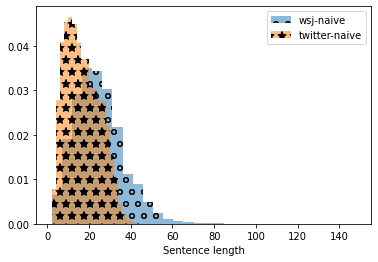

In [27]:
_ = plt.hist(wsj_naive_length, label='wsj-naive', bins=30, alpha=0.5, hatch='o', density=True)
_ = plt.hist(twitter_naive_length, label='twitter-naive', bins=30, alpha=0.5, hatch='*', density=True)
_ = plt.xlabel('Sentence length')
_ = plt.legend()

# <a name="analysis"> Analysing Basic Properties of Corpora

Besides models and algorithms, NLTK also provides access to corpora. 

You can check the documentation of the [corpus package](https://www.nltk.org/api/nltk.corpus.html#module-nltk.corpus) online or on your own jupyter notebook using `nltk.corpus?`. Here is a [list of available corpora](http://www.nltk.org/nltk_data/).

Corpora in NLTK are mostly already pre-processed at the basic levels (e.g., sentence splitting, and tokenization). 

Let's have a look at sample from the English PeenTreebank (again, a section of the WSJ corpus). If you are a Dutch speaker, you can also check Alpino (Dutch). 

In [28]:
from nltk.corpus import treebank as en_ptb  # We are renaming this to en_ptb (English Penn Treebank)

In [29]:
#from nltk.corpus import alpino

In [30]:
len(en_ptb.sents())

3914

Inspect some sentences:

In [31]:
for sid, sent in zip(range(5), en_ptb.sents()):
    print(sent)

['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']
['Mr.', 'Vinken', 'is', 'chairman', 'of', 'Elsevier', 'N.V.', ',', 'the', 'Dutch', 'publishing', 'group', '.']
['Rudolph', 'Agnew', ',', '55', 'years', 'old', 'and', 'former', 'chairman', 'of', 'Consolidated', 'Gold', 'Fields', 'PLC', ',', 'was', 'named', '*-1', 'a', 'nonexecutive', 'director', 'of', 'this', 'British', 'industrial', 'conglomerate', '.']
['A', 'form', 'of', 'asbestos', 'once', 'used', '*', '*', 'to', 'make', 'Kent', 'cigarette', 'filters', 'has', 'caused', 'a', 'high', 'percentage', 'of', 'cancer', 'deaths', 'among', 'a', 'group', 'of', 'workers', 'exposed', '*', 'to', 'it', 'more', 'than', '30', 'years', 'ago', ',', 'researchers', 'reported', '0', '*T*-1', '.']
['The', 'asbestos', 'fiber', ',', 'crocidolite', ',', 'is', 'unusually', 'resilient', 'once', 'it', 'enters', 'the', 'lungs', ',', 'with', 'even', 'brief', 'exposures', '

In this class we will begin to analyse text, and we will begin to appreciate the power of the statistical approach to NLP. In order to demonstrate some interesting things later on, let's seperate our corpora into disjoint subsets which we will call *training* and *test*. Here's a helper function for that:

In [32]:
import numpy as np

def split_corpus(sentences, ratio=0.9):
    """
    Randomly split a list of sentences into two sets according to the given ratio.
    
    :param sentences: already tokenized sentences (list of strings)
    """
    # This will guarantee that the permutation is the same every time (which is important for reproducibility)
    rng = np.random.RandomState(42)
    rng.permutation(5)
    indices = rng.permutation(len(sentences))
    n = int(indices.size * ratio)
    return [sentences[i] for i in indices[:n]], [sentences[i] for i in indices[n:]]

In [33]:
en_ptb_training, en_ptb_test = split_corpus(en_ptb.sents(), ratio=0.9)
print("Random split of the English Penn Treebank: training={} test={}".format(len(en_ptb_training), len(en_ptb_test)))

Random split of the English Penn Treebank: training=3522 test=392


## <a name="length">  Sentence Length

**EXERCISES**

1. Load sentences from `twitter_sample.txt` and tokenize them using `TweetTokenizer`.
2. Load sentences from NLTK's `treebank` (note that they are already tokenized).
3. For each corpus, use 80% for `training` and 20% for `test` (it's a good idea to randomize the split as shown in the code above).
4. Estimate and plot the length distribution of each portion of each of the corpus. Note how the training and test distribution of a given corpus are reasonably similar (if you plot with `plt.hist`, the argument `density=True` will help you see this more clearly). 
5. Compute and list summary statistics (e.g., mean, standard deviation, min, max, median) of the length distributions you estimated earlier. 
6. Use a [boxplot](https://matplotlib.org/3.3.3/api/_as_gen/matplotlib.pyplot.boxplot.html) to visualize the spread of the length distributions.
7. Load the files `test_a.txt` and `test_b.txt`. These two files have already been segmented into sentences (using newline as a delimiter) and into tokens (using space as a delimiter). Can you use statistics about length to classify each of these files into one of the two genres we have come across so far (i.e., newswire or twitter)? Explain you reasoning.

<details>
    <summary> <b>SOLUTIONS</b> </summary>

```python

# Plot length distribution for PTB
_ = plt.hist(np.array([len(s) for s in en_ptb_training]), label='en_ptb training', bins=30, alpha=0.5, hatch='o', density=True)
_ = plt.hist(np.array([len(s) for s in en_ptb_test]), label='en_ptb test', bins=30, alpha=0.5, hatch='*', density=True)
_ = plt.xlabel('Sentence length')
_ = plt.legend()  
plt.show()
    
# Split twitter data    
en_twitter_training, en_twitter_test = split_corpus([tweet_tokenizer.tokenize(s) for s in twitter_sample], ratio=0.8)
print(len(en_twitter_training), len(en_twitter_test))
    
# Plot length distribution for twitter
_ = plt.hist(np.array([len(s) for s in en_twitter_training]), label='en_twitter training', bins=30, alpha=0.5, hatch='o', density=True)
_ = plt.hist(np.array([len(s) for s in en_twitter_test]), label='en_twitter test', bins=30, alpha=0.5, hatch='*', density=True)
_ = plt.xlabel('Sentence length')
_ = plt.legend()    
plt.show()
    
# Boxplots
_ = plt.boxplot(
    [
        np.array([len(s) for s in en_ptb_training]),
        np.array([len(s) for s in en_ptb_test]),
    ], labels=['ptb_training', 'ptb_test']
)
plt.show()
_ = plt.boxplot(
    [
        np.array([len(s) for s in en_twitter_training]),
        np.array([len(s) for s in en_twitter_test]),
    ], labels=['twitter_training', 'twitter_test']
)
plt.show()
_ = plt.boxplot(
    [     
        np.array([len(s.split()) for s in open('test_a.txt').readlines()]),
        np.array([len(s.split()) for s in open('test_b.txt').readlines()])
    ], labels=['test_a', 'test_b']
)
plt.show() # test_a is a lot more like twitter


# Compare training sets, test sets, and unknown test sets
headers = ['corpus', 'split', 'mean-length']
rows = [
    ['en_ptb', 'training', np.array([len(s) for s in en_ptb_training]).mean()],
    ['en_ptb', 'test', np.array([len(s) for s in en_ptb_test]).mean()],
    ['twitter', 'training', np.array([len(s) for s in en_twitter_training]).mean()],
    ['twitter', 'test', np.array([len(s) for s in en_twitter_test]).mean()],
    ['a', 'test', np.array([len(s.split()) for s in open('test_a.txt').readlines()]).mean()],
    ['b', 'test', np.array([len(s.split()) for s in open('test_b.txt').readlines()]).mean()]
]
print(tabulate(rows, headers=headers))

```

</details>

---

## <a name="vocabulary"> Vocabulary


Natural languages are remarkably productive, an human speakers are very creative. Day after day, the vocabulary of every natural language actively spoken on the planet is continuously changing. New words are created, existing words are reused in novel ways, some words lose their prominence.

In most NLP applications the vocabulary of a language is frozen. We consider a "vocabulary" the set of all known types at a given time. Here we use the word *type* to distinguish, for example, the unique token `the` from its many occurrences in a corpus, which we usually call *instances*).

Entries in a vocabulary are generally referred to as *words*, but in NLP they really are *tokens*, where a *token* is whatever sequence of characters that we treat as a unit (typically a sequence of non-blank characters). For example, linguistically speaking `Oct.` is not a word (it's an abbreviated form of the word `October`), but it may well be a token in our NLP system's vocabulary. Conversely, `camera-ready` is a word in English, but any one occurrence of `camera-ready` may be split into one or more tokens depending on our tokenization strategy (e.g., `camera`, `-`, `ready`). Moreover, while linguistically `Oct.` really is an instance of the word `October`, unless we are explicit about it, a computer cannot tell that. NLP systems won't be able to infer the relationship between these two strings, `Oct.` and `October`, unless we give them the means to do so. 

We will now begin to appreciate one of the most important aspects of written language: *data sparsity*. Data sparsity affects many aspects of NLP systems, and a system's vocabulary is probably the best example.

You are probably aware of [Zipf's law](https://en.wikipedia.org/wiki/Zipf%27s_law), an empirical finding that the frequency of any word (which we can safely approximate to a token) is inversely proportional to its rank in the frequency table.

We will now verify this finding. For that, we need to determine the number of occurrences of each token in the vocabulary of a given corpus. In python, a `Counter` (from `collections`) can help us achieve that (if you are not familiar with `Counter` but now `dict`, they are very similar, check the python docs).

In [34]:
from collections import Counter

In [35]:
counter = Counter()
for sentence in en_ptb.sents():  # for each sentence 
    counter.update(sentence)  # count occurrences of word types (tokens)

The counter stores a dictionary where each key is an observed token and its value is the number of times it occurred.

In [36]:
'day' in counter.keys(), counter['day']

(True, 23)

In [37]:
'NTMI' in counter.keys()  # it looks like our course has not been mentioned in the WSJ yet ;)

False

Counters can sort the vocabulary for us!

In [38]:
counter.most_common(10)  # here we're listing only the top-10 for visualization purposes

[(',', 4885),
 ('the', 4045),
 ('.', 3828),
 ('of', 2319),
 ('to', 2164),
 ('a', 1878),
 ('in', 1572),
 ('and', 1511),
 ('*-1', 1123),
 ('0', 1099)]

**EXERCISE**

Plot the rank vs frequency to visualize Zipf's law (use for example the sentences in the English Penn Treebank). If you use `plt.loglog` plot, that is, a plot with logarithmic axes, the curve should look roughly like a straight line. 

<details>
    <summary> <b> SOLUTION </b> </summary>

```python
en_ptb_vocabulary, en_ptb_freq = zip(*counter.most_common()) 
_ = plt.loglog(np.arange(len(en_ptb_vocabulary)), en_ptb_freq, label='en_ptb')
_ = plt.xlabel('Log Rank')
_ = plt.ylabel('Log Frequency')
_ = plt.legend()
_ = plt.title("Zipf's law")
plt.show()    
    
```    

</details>
    
---    

You might have noticed another aspect of written English that contributes to data sparsity: uppercasing. 

In most contexts, `day` and `Day` probably refer to the exact same type (a day, like today or tomorrow).

In [39]:
'day' in counter,  'Day' in counter

(True, True)

In [40]:
counter['day'], counter['Day']

(23, 1)

Unfortunately, the `Counter` cannot know that instances of `day` and `Day` should count towards occurrences of the same type. They do differ at the representation level:

In [41]:
str('day') == str('Day')

False

One way to deal with that is to lowercase the data as a pre-processing step. This has downsides, can you think of some?

This is not the only issue contributing to sparse vocabularies. Morhopological inflection does that too, for example, singular vs plural, gender marking, syntactic case, all these linguistic devices contribute to data sparsity, and in some applications we might want to treat all instances of `day`, `Day`, `days`, and `Days` as if they referred to the same type (the English word `DAY`).

One relatively simple way to reduce the vocabulary size by collapsing different variants of a certain base form is to use a [stemmer](https://en.wikipedia.org/wiki/Stemming). NLTK provides options for a few languages inclugin [English and Dutch](https://www.nltk.org/api/nltk.stem.html). 

Here is an example of what stemmers do:

In [42]:
from nltk.stem.snowball import EnglishStemmer

In [43]:
en_stemmer = EnglishStemmer()

In [44]:
for i, s in zip(range(3), en_ptb.sents()):
    rows = []
    rows.extend([(w, en_stemmer.stem(w)) for w in s])
    print(tabulate(rows, headers=['word', 'stem']))
    print()

word          stem
------------  ---------
Pierre        pierr
Vinken        vinken
,             ,
61            61
years         year
old           old
,             ,
will          will
join          join
the           the
board         board
as            as
a             a
nonexecutive  nonexecut
director      director
Nov.          nov.
29            29
.             .

word        stem
----------  --------
Mr.         mr.
Vinken      vinken
is          is
chairman    chairman
of          of
Elsevier    elsevi
N.V.        n.v.
,           ,
the         the
Dutch       dutch
publishing  publish
group       group
.           .

word          stem
------------  ---------
Rudolph       rudolph
Agnew         agnew
,             ,
55            55
years         year
old           old
and           and
former        former
chairman      chairman
of            of
Consolidated  consolid
Gold          gold
Fields        field
PLC           plc
,             ,
was           was
named       

**EXERCISE**

Implement text normalization strategies aimed at reducing data sparsity, such as lowercasing or [truecasing](https://en.wikipedia.org/wiki/Truecasing), and/or stemming. 
Analyse the resulting vocabularies before and after the normalization steps (e.g., vocabulary size in number of types, rank-vs-frequency plot).

# <a name="unigram"> Unigram Language Model

Here we encounter our first statistical model in NLP, namely, the *unigram language model*. If you feel like you need a refresher on basic probability, check [this notebook](../R1/R1.ipynb).

A **language model** is a probability distribution over *finite sequences of words*. These sequences may be interpreted as sentences, paragraphs, or documents, but for ease of presentation we will refer to them as sentences.

Let $S$ be a random variable that takes on values in the space $\Sigma^*$, which includes all English sentences (English is our running example). We can treat $S$ as a sequence of finitely many random tokens, i.e.,  $S=X_{1:m}=\langle X_1, \ldots, X_m \rangle$, where each token $X_i$ takes on values in an enumeration $\mathcal X$ of the English vocabulary $\Sigma$, and the last token corresponds to a special end-of-sequence (EOS) symbol, i.e., $X_m=\text{EOS}$ (with some abuse of notation we use the symbol itself instead of the numerical outcome that corresponds to it).  

By **chain rule**, we know that we can factorise the joint probability $P_{X_{1:m}}(x_{1:m})$ of a sequence $x_{1:m}=\langle x_1, \ldots, x_m\rangle$ as follows

\begin{align}
    P_{X_{1:m}}(x_{1:m}) &= \prod_{i=1}^m P_{X_i|X_{<i}}(x_i|x_{<i})
\end{align}

where we use $x_{<i}$ as a shorthand for the $i$th prefix sequence (i.e., $x_{<i} = \langle \rangle$ is empty if $i=1$, oterhwise $x_{<i} = \langle x_1, \ldots, x_{i-1}\rangle$).

The **unigram language model** assumes that the distribution of $X_i$ is independent of $X_{<i}$  and of the position $i$ of the token. Mathematically, this is denoted $X_i \perp X_{<i}$. Under such **independence assumption** we can simplify the chain rule:

\begin{align}
    P_{X_{1:m}}(x_{1:m}) &\overset{\text{ind.}}{\triangleq} \prod_{i=1}^m P_{X}(x_i)
\end{align}

Note that the chain rule is a general result from probability theory, no matter the probability distribution, it always holds. The simplification above is a *design choice* or a *modelling assumption* which may or may no be realistic in practice.

We have simplified our model of the joint distribution over $X_{1:m}$ such that a sentence is a sequence of repeated draws from the same distribution over random words. We can now make a **parametric assumption**, in particular, we choose to model $X$ using a Categorical distribution with fixed parameters $\theta_{1:v} \in \Delta^{v-1}$, where $v$ is the vocabulary size. A compact way to denote this choice is $X_i \perp X_{<i} \sim \text{Cat}(\theta_{1:v})$ or simply $X \sim \text{Cat}(\theta_{1:v})$.

---
<details>
    <summary>If you are not familiar with this symbol $\Delta^{v-1}$</summary>

it denotes the [($v-1$)-dimensional simplex](https://en.wikipedia.org/wiki/Simplex), or the space of $v$-dimensional probability vectors. A vector in this space contains $v$ coordinates, each of which is between $0$ and $1$,  whose sum is exactly $1$. A point in the simplex parameterises a discrete distribution over $v$ outcomes.

</details>

---
    
Given our independence assumption and our choice of parameterisation, the joint probability of a sentence under the unigram LM is defined as:

\begin{align}
    P_{X_{1:m}}(x_{1:m}|\theta) &\overset{\text{ind.}}{\triangleq} \prod_{i=1}^m \text{Cat}(x_i|\theta_{1:v}) =  \prod_{i=1}^m\theta_{x_i}
\end{align}

This completes the design of the unigram language model. Note that in the last equation we use the probability mass function of the Categorical distribution to specify the joint probability of a sentence under the unigram LM.

We can also state the unigram LM in terms of a generative story:

* For each step $i$ of a sequence, draw $X_i$ from $\text{Categorical}(\theta_{1:v})$ until you draw a special end-of-sequence token (i.e., $X_i=\text{EOS}$)

Given a dataset $\mathcal D$ of $K$ observations (i.e., a collection of observed sequences), each denoted $x_{1:m_k}^{(k)}$ where $m_k$ is the length of the $k$th observation, we can approach **parameter estimation** for this model via the *maximum likelihood principle*. 

The entire model is specified by a single Categorical distribution whose MLE solution is:

\begin{align}
\theta_x &= \frac{\mathrm{count}_X(x)}{\sum_{x' \in \mathcal X} \mathrm{count}_X(x')}
\end{align}

where $\mathrm{count}_X(x) = \sum_{k=1}^K \sum_{i=1}^{m_k} [x^{(k)}_i = x]$ counts the number of occurrences of $X=x$ in $\mathcal D$.
    
---
<details>
    <summary>The Iverson bracket $[\text{predicate}]$</summary>

casts the result of a boolean expression to integer, that is, it returns $1$ if the predicate is true, or $0$ otherwise. You can read more on this [wikipedia page](https://en.wikipedia.org/wiki/Iverson_bracket).

</details>

---



Finally, note that 

* the **space** used by this model is bounded by a linear function of vocabulary size (we need to store one real number per token in the vocabulary), so we say its [space complexity](https://en.wikipedia.org/wiki/Space_complexity) is $\mathcal O(v)$
* the **time** necessary to assess the joint probability of any given sequence $x_{1:m}$ is bounded by a linear function of $m$ (as we need to look up $n$ probability values and multiply them together), so we say the [time complexity](https://en.wikipedia.org/wiki/Time_complexity) of this procedure is $\mathcal O(m)$


**Warning** If the language and/or the notation in this section posed challenges to you, you probably need a [refresher on probability theory](../R1/R1.ipynb).

**EXERCISES**

1. Estimate the parameters of a unigram LM based on a corpus of your choice
2. Report the entropy of the unigram distribution
3. Draw sentences from the model and try to explain why they do not look like sentences at all
4. Use your model to simulate a dataset of size comparable to your training data (or test data). Compare basic statistics (e.g., average length, token frequency) of the simulated data to statistics of the real data. 
5. Even though the simulated data won't *look like* sentences, certain statistics of real data can be reproduced well. Can you explain why? 
6. Can you imagine one statistic that simulated data should not be able to reproduce well?


<details>
    <summary> <b> SOLUTION </b> </summary>

```python

# Count unigrams
unigram_counter = Counter()
for sentence in en_ptb.sents():  # for each sentence 
    unigram_counter.update(sentence + ['</s>'])  # the unigram LM's generative story requires a EOS token

# Unigrams (the order is not important as long as it is fixed and consistent with the order we build the count vector)
unigrams = [w for w, n in unigram_counter.most_common()]
# Counts
counts = np.array([n for w, n in unigram_counter.most_common()])
# MLE solution
probs = counts / counts.sum()
assert np.all(probs >= 0), "Probabilities are lowerbounded by 0"
assert np.all(probs <= 1), "Probabilities are uppebounded by 1"
assert np.isclose(probs.sum(), 1, 0.001), "The parameters of a Categorical distribution must add up to 1.0"
print("Entropy: {:.2f}".format((-probs*np.log(probs)).sum()))

def sample_sentence(probs, vocab, max_length=200):
    """
    Draws a sentence (a list of tokens ending with the EOS token) 
     following the unigram LM's generative story
     
    :probs: the parameter of a categorical distribution
    :vocab: the words mapped to the outcomes in the support of the categorical distribution
    :max_length: prevents infinite loops (in case for some unfortunate reason, we never sample the EOS token)
    """
    s = []
    vocab_size = len(vocab)
    for _ in range(max_length):
        i = np.random.choice(vocab_size, p=probs)
        s.append(vocab[i])
        if s[-1] == '</s>':  # if we sampled the EOS token, we stop
            return s
    return s
print('Generated sentence:', ' '.join(sample_sentence(probs, unigrams)))

print("Simulating data (may take a moment)...")
# Simulate a dataset as large as the PTB
generated_ptb = [sample_sentence(probs, unigrams) for _ in range(len(en_ptb.sents()))]
# Length distribution
#  to compare length, I am discounting the EOS since the PTB does not come with it
generated_L = np.array([len(s) - 1 for s in generated_ptb])  
observed_L = np.array([len(s) for s in en_ptb.sents()])
print('Average length is captured well: generated={:.2f} observed={:.2f}'.format(generated_L.mean(), observed_L.mean()))

# The length distribution is not captured well, even though average length is captured well
_ = plt.hist(observed_L, bins=30, label='ptb_observed')
_ = plt.hist(generated_L, bins=30, label='ptb_generated')
_ = plt.xlabel('Sequence length')
_ = plt.legend()
plt.show()

```

The model cannot capture complex dependencies amongst tokens, since we made a strong independence assumption, but it can capture marginal word frequencies through the unigram distribution. 

If we are careful to include the EOS token, as we should since we made it part of the unigram LM's generative story, then the model can also capture average sentence length: imagine that if EOS has probability about 1/20, then it will take on average 20 draws until we see it (and thus end the sentence).
A length distribution governed by a single probability value would look like a Geometric distribution, but most corpora exhibit length distributions that look more like a Poisson, thus though the model can capture the average length, it probably cannot capture the shape of the length distribution.

Statistics that depend on the interaction amongst tokens are far beyond this model, for example, this model could not get the frequency of collocations or multi-word expressions since none of its factors can score such outcomes higher than the product of their corresponding parts.
    

</details>

---

Entropy: 6.85
Generated sentence: The said time * advertisers S. </s>
Simulating data (may take a moment)...
Average length is captured well: generated=25.32 observed=25.72


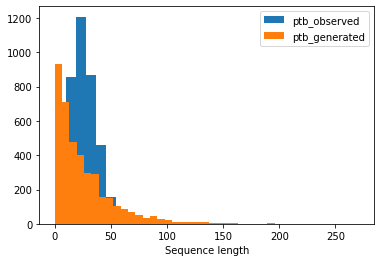

In [45]:
# Count unigrams
unigram_counter = Counter()
for sentence in en_ptb.sents():  # for each sentence 
    unigram_counter.update(sentence + ['</s>'])  # the unigram LM's generative story requires a EOS token

# Unigrams (the order is not important as long as it is fixed and consistent with the order we build the count vector)
unigrams = [w for w, n in unigram_counter.most_common()]
# Counts
counts = np.array([n for w, n in unigram_counter.most_common()])
# MLE solution
probs = counts / counts.sum()
assert np.all(probs >= 0), "Probabilities are lowerbounded by 0"
assert np.all(probs <= 1), "Probabilities are uppebounded by 1"
assert np.isclose(probs.sum(), 1, 0.001), "The parameters of a Categorical distribution must add up to 1.0"
print("Entropy: {:.2f}".format((-probs*np.log(probs)).sum()))

def sample_sentence(probs, vocab, max_length=200):
    """
    Draws a sentence (a list of tokens ending with the EOS token) 
     following the unigram LM's generative story

    :probs: the parameter of a categorical distribution
    :vocab: the words mapped to the outcomes in the support of the categorical distribution
    :max_length: prevents infinite loops (in case for some unfortunate reason, we never sample the EOS token)
    """
    s = []
    vocab_size = len(vocab)
    for _ in range(max_length):
        i = np.random.choice(vocab_size, p=probs)
        s.append(vocab[i])
        if s[-1] == '</s>':  # if we sampled the EOS token, we stop
            return s
    return s
print('Generated sentence:', ' '.join(sample_sentence(probs, unigrams)))

print("Simulating data (may take a moment)...")
# Simulate a dataset as large as the PTB
generated_ptb = [sample_sentence(probs, unigrams) for _ in range(len(en_ptb.sents()))]
# Length distribution
#  to compare length, I am discounting the EOS since the PTB does not come with it
generated_L = np.array([len(s) - 1 for s in generated_ptb])  
observed_L = np.array([len(s) for s in en_ptb.sents()])
print('Average length is captured well: generated={:.2f} observed={:.2f}'.format(generated_L.mean(), observed_L.mean()))

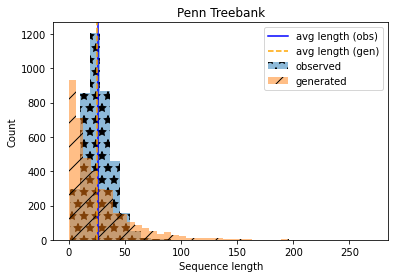

In [72]:
# The length distribution is not captured well, even though average length is captured well
_ = plt.hist(observed_L, bins=30, alpha=0.5, hatch='*', label='observed')
_ = plt.hist(generated_L, bins=30, alpha=0.5, hatch='/', label='generated')
_ = plt.xlabel('Sequence length')
_ = plt.ylabel('Count')
_ = plt.title('Penn Treebank')
_ = plt.axvline(x=observed_L.mean(), ls='-', c='blue', label='avg length (obs)')
_ = plt.axvline(x=generated_L.mean(), ls='--', c='orange', label='avg length (gen)')
_ = plt.legend()
plt.savefig('ptb_length.png')
plt.show()

In [46]:
import scipy as sp
from scipy import stats as st

In [47]:
import pandas as pd

In [48]:
pd.DataFrame(dict(generated=generated_L, observed=observed_L)).describe()

,generated,observed
count,3914.000000,3914.000000
mean,25.322688,25.722024
std,25.708988,12.868534
min,0.000000,1.000000
25%,7.000000,17.000000
50%,17.000000,25.000000
75%,35.000000,33.000000
max,196.000000,271.000000


In [49]:
from itertools import chain

gen_counts = np.array([n for n in Counter(chain(*generated_ptb)).values()])

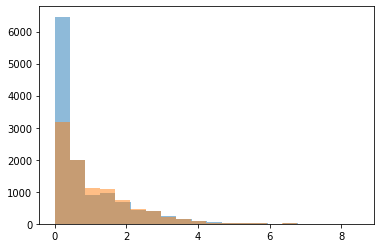

In [50]:
_ = plt.hist(np.log(counts), bins=20, alpha=0.5, density=False, label='ptb_observed')
_ = plt.hist(np.log(gen_counts), bins=20, alpha=0.5, density=False, label='ptb_generated')